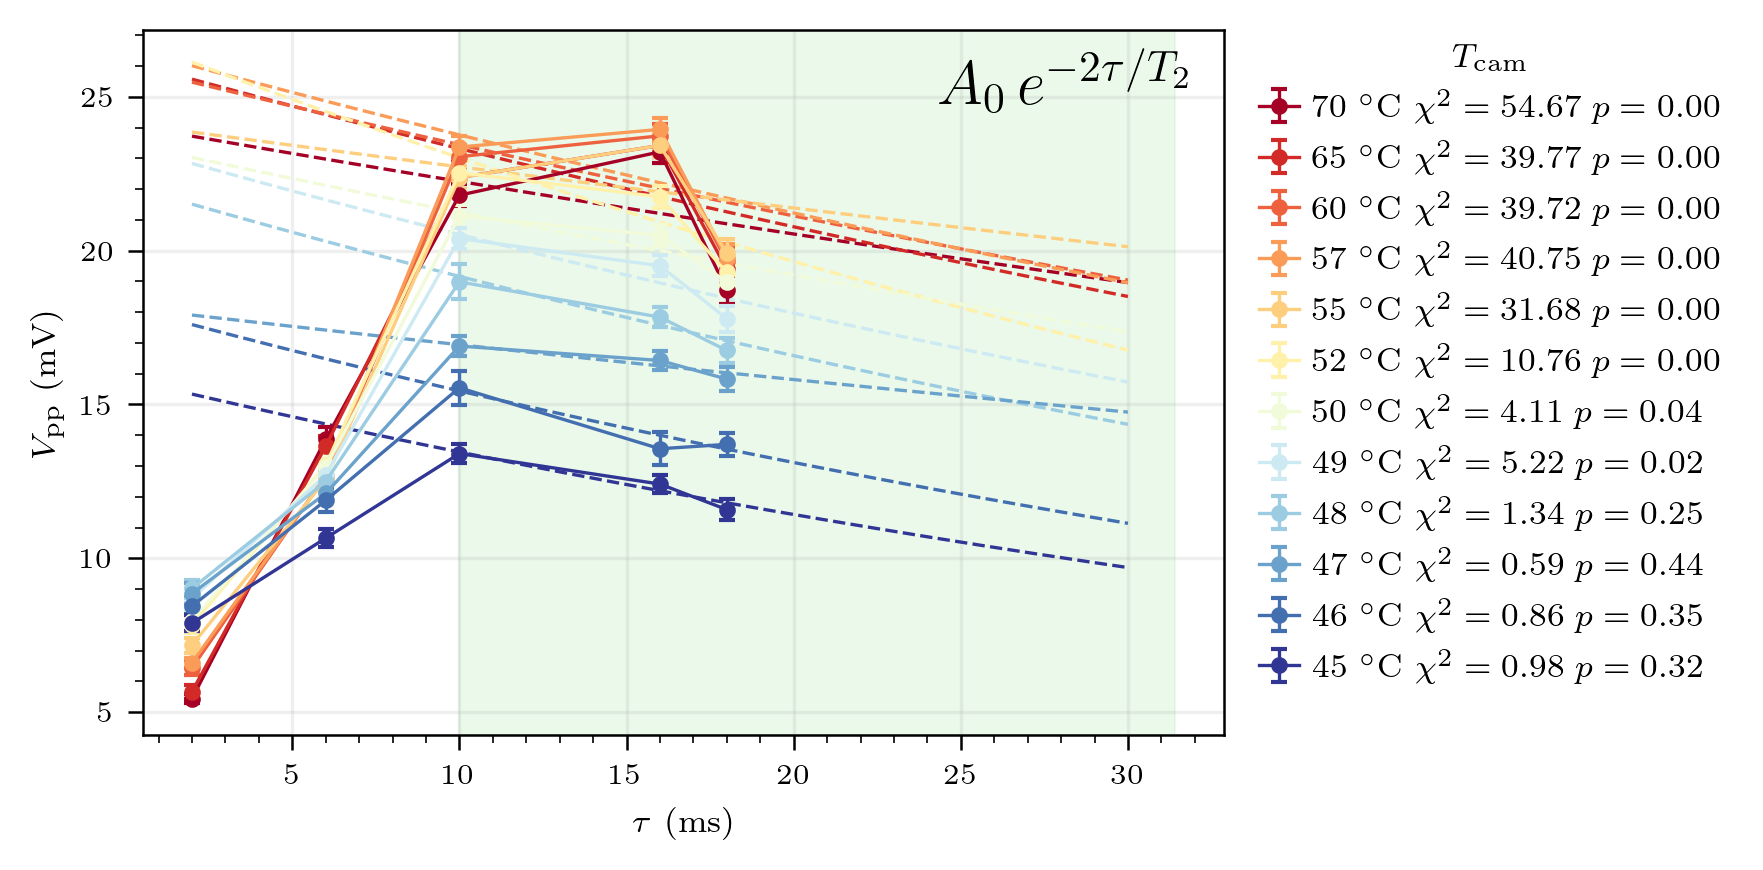

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
from scipy.stats import chi2 as chi2_dist

plt.style.use('./jlab.mplstyle')

# --- Parse bwax_data_new.csv ---
# Row layout (after header):
#   row  0    : tau values (ms)
#   row  1    : repeat times TR (ms)
#   rows 2–13 : temperature data (one row per temperature)
#   row  14   : calibration bar height (px)
#   row  15   : calibration bar height (mV)
# Columns alternate: [label, val0, unc0, val1, unc1, ..., val4, unc4]

df = pd.read_csv('bwax_data_new.csv', header=0)

tau_row      = df.iloc[0]
temp_df      = df.iloc[2:14]
calib_px_row = df.iloc[14]
calib_mV_row = df.iloc[15]

val_slice = slice(1, None, 2)
unc_slice = slice(2, None, 2)

temperatures = temp_df.iloc[:, 0].values.astype(float)
raw_px       = temp_df.iloc[:, val_slice].values.astype(float)
raw_unc      = temp_df.iloc[:, unc_slice].values.astype(float)

taus     = tau_row.iloc[val_slice].values.astype(float)
calib_px = calib_px_row.iloc[val_slice].values.astype(float)
calib_unc= calib_px_row.iloc[unc_slice].values.astype(float)
calib_mV = calib_mV_row.iloc[val_slice].values.astype(float)

# --- Pixel → mV conversion ---
scale      = calib_mV / calib_px
amp_mV     = raw_px * scale[np.newaxis, :]
amp_unc_mV = amp_mV * np.sqrt((raw_unc / raw_px)**2 + (calib_unc / calib_px)**2)

# --- Exponential decay fit (T2) on tau = 10, 16, 18 ms ---
# Model: A(τ) = A0 * exp(−2τ / T2)
fit_mask = np.isin(taus, [10, 16, 18])
taus_fit = taus[fit_mask]
dof = len(taus_fit) - 2  # 3 points, 2 params

def exp_decay(tau, A0, T2):
    return A0 * np.exp(-2 * tau / T2)

T2_vals   = np.zeros(len(temperatures))
T2_errs   = np.zeros(len(temperatures))
A0_vals   = np.zeros(len(temperatures))
chi2_vals = np.zeros(len(temperatures))

for i in range(len(temperatures)):
    y    = amp_mV[i, fit_mask]
    yerr = amp_unc_mV[i, fit_mask]
    p0   = [y[0] * np.exp(taus_fit[0] / 15), 15.0]
    popt, pcov = curve_fit(exp_decay, taus_fit, y, p0=p0, sigma=yerr, absolute_sigma=True)
    A0_vals[i]   = popt[0]
    T2_vals[i]   = popt[1]
    T2_errs[i]   = np.sqrt(pcov[1, 1])
    residuals    = (y - exp_decay(taus_fit, *popt)) / yerr
    chi2_vals[i] = np.sum(residuals**2)

p_vals = chi2_dist.sf(chi2_vals, df=dof)

# --- Plot 1: Amplitude vs tau with exponential fits ---
n      = len(temperatures)
colors = [cm.RdYlBu_r((n - 1 - i) / (n - 1)) for i in range(n)]
tau_fine = np.linspace(2, 30, 300)

fig, ax = plt.subplots(figsize=(6, 3))

for i, T in enumerate(temperatures):
    label = rf'${T:.0f}\ ^\circ$C  $\chi^2={chi2_vals[i]:.2f}$  $p={p_vals[i]:.2f}$'
    ax.errorbar(taus, amp_mV[i], yerr=amp_unc_mV[i],
                fmt='o-', color=colors[i], capsize=2, lw=0.8, markersize=3,
                zorder=3, label=label)
    ax.plot(tau_fine, exp_decay(tau_fine, A0_vals[i], T2_vals[i]),
            color=colors[i], lw=0.8, ls='--', zorder=2)

# Shade region used in fit (tau >= 10)
ax.axvspan(10, ax.get_xlim()[1], color='limegreen', alpha=0.1, zorder=1)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8,
          handlelength=1.2, handletextpad=0.4, borderaxespad=0,
          title=r'$T_\mathrm{cam}$', title_fontsize=8)

ax.text(0.97, 0.97, r'$A_0\,e^{-2\tau/T_2}$', transform=ax.transAxes,
        ha='right', va='top', fontsize=15)

ax.set_xlabel(r'$\tau$ (ms)')
ax.set_ylabel(r'$V_\mathrm{pp}$ (mV)')
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig('bwax_amplitude_vs_tau.png', dpi=300, bbox_inches='tight')
fig.savefig('bwax_amplitude_vs_tau.pdf', bbox_inches='tight')
plt.show()


In [94]:
p_vals = chi2_dist.sf(chi2_vals, df=dof)

table = pd.DataFrame({
    r'$T_\mathrm{cam}$ (°C)': temperatures.astype(int),
    r'$\chi^2$':              np.round(chi2_vals, 3),
    r'$\nu$':                 [dof] * len(temperatures),
    r'$\chi^2/\nu$':          np.round(chi2_vals / dof, 3),
    r'$p$':                   np.round(p_vals, 3),
})
table.index = [''] * len(table)
display(table)

,$T_\mathrm{cam}$ (°C),$\chi^2$,$\nu$,$\chi^2/\nu$,$p$
,70,54.667,1,54.667,0.000
,65,39.772,1,39.772,0.000
,60,39.718,1,39.718,0.000
,57,40.752,1,40.752,0.000
,55,31.679,1,31.679,0.000
,52,10.759,1,10.759,0.001
,50,4.114,1,4.114,0.043
,49,5.217,1,5.217,0.022
,48,1.342,1,1.342,0.247
,47,0.588,1,0.588,0.443


The camera records temperature at discrete times, so a 1-second timing uncertainty $\Delta t = 1\ \text{s}$ propagates into a temperature uncertainty via

$$\sigma_T = \left|\frac{dT}{dt}\right| \Delta t$$

where $|dT/dt|$ is estimated from the calibration data. The derivative is approximated using central finite differences at interior points,

$$\left.\frac{dT}{dt}\right|_i = \frac{T_{i+1} - T_{i-1}}{t_{i+1} - t_{i-1}}$$

and one-sided differences at the endpoints. Since the calibration was repeated for each of the $N_\tau = 5$ pulse spacings $\tau$, the derivative estimates are interpolated to each measurement temperature and averaged across runs:

$$\sigma_T(T) = \Delta t \cdot \frac{1}{N_\tau} \sum_{k=1}^{N_\tau} \left|\frac{dT}{dt}\right|_k(T)$$

T_cam uncertainties from 1-s timing delay:
  T_cam = 70 °C  →  σ_T = 0.271 °C
  T_cam = 65 °C  →  σ_T = 0.342 °C
  T_cam = 60 °C  →  σ_T = 0.186 °C
  T_cam = 57 °C  →  σ_T = 0.148 °C
  T_cam = 55 °C  →  σ_T = 0.125 °C
  T_cam = 52 °C  →  σ_T = 0.058 °C
  T_cam = 50 °C  →  σ_T = 0.044 °C
  T_cam = 49 °C  →  σ_T = 0.038 °C
  T_cam = 48 °C  →  σ_T = 0.031 °C
  T_cam = 47 °C  →  σ_T = 0.028 °C
  T_cam = 46 °C  →  σ_T = 0.027 °C
  T_cam = 45 °C  →  σ_T = 0.027 °C


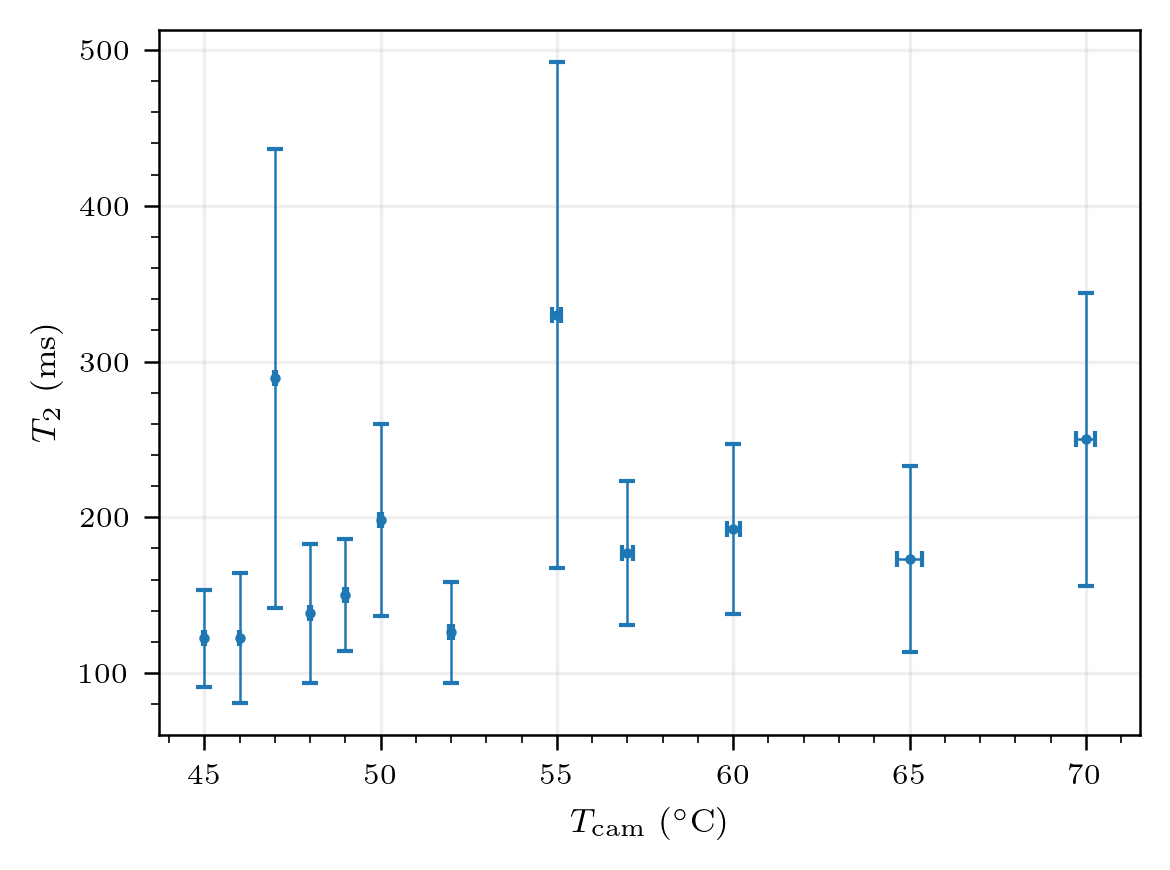

In [95]:
# --- Load temperature calibration data ---
cal_df = pd.read_csv('beeswax_temp_calibration.csv', header=None, skiprows=2,
                     names=['T', 't2', 'u2', 't6', 'u6', 't10', 'u10', 't16', 'u16', 't18', 'u18'])
cal_df['T'] = pd.to_numeric(cal_df['T'], errors='coerce')
cal_df = cal_df.dropna(subset=['T']).reset_index(drop=True)

t_cols = ['t2', 't6', 't10', 't16', 't18']
for col in t_cols:
    cal_df[col] = pd.to_numeric(cal_df[col], errors='coerce')

T_cal = cal_df['T'].values.astype(float)   # 71 → 45 °C, decreasing

# For each tau column: compute |dT/dt| on valid (non-NaN) rows only, then
# interpolate to the temperatures of interest (NaN rows are skipped — their
# nearest valid neighbours are used automatically by np.interp).
dTdt_all = []
for col in t_cols:
    t_col = cal_df[col].values.astype(float)
    valid = ~np.isnan(t_col)
    T_valid = T_cal[valid]
    t_valid = t_col[valid]

    dTdt_valid = np.gradient(T_valid, t_valid)   # dT/dt < 0 (cooling)

    idx_sort = np.argsort(T_valid)               # np.interp needs ascending x
    dTdt_interp = np.interp(temperatures,
                            T_valid[idx_sort],
                            dTdt_valid[idx_sort])
    dTdt_all.append(np.abs(dTdt_interp))

# Average |dT/dt| across all tau calibrations, then σ_T = |dT/dt| × 1 s
sigma_T = np.mean(dTdt_all, axis=0) * 1.0

print("T_cam uncertainties from 1-s timing delay:")
for T, s in zip(temperatures, sigma_T):
    print(f"  T_cam = {T:.0f} °C  →  σ_T = {s:.3f} °C")

# --- Plot 2: T2 vs T_cam ---
fig, ax = plt.subplots(figsize=(4, 3))

ax.errorbar(temperatures, T2_vals, yerr=T2_errs, xerr=sigma_T,
            fmt='o', capsize=2, markersize=1.5, color='tab:blue')

ax.set_xlabel(r'$T_\mathrm{cam}$ ($^\circ$C)')
ax.set_ylabel(r'$T_2$ (ms)')
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig('bwax_T2_vs_Tcam.png', dpi=300, bbox_inches='tight')
fig.savefig('bwax_T2_vs_Tcam.pdf', bbox_inches='tight')
plt.show()


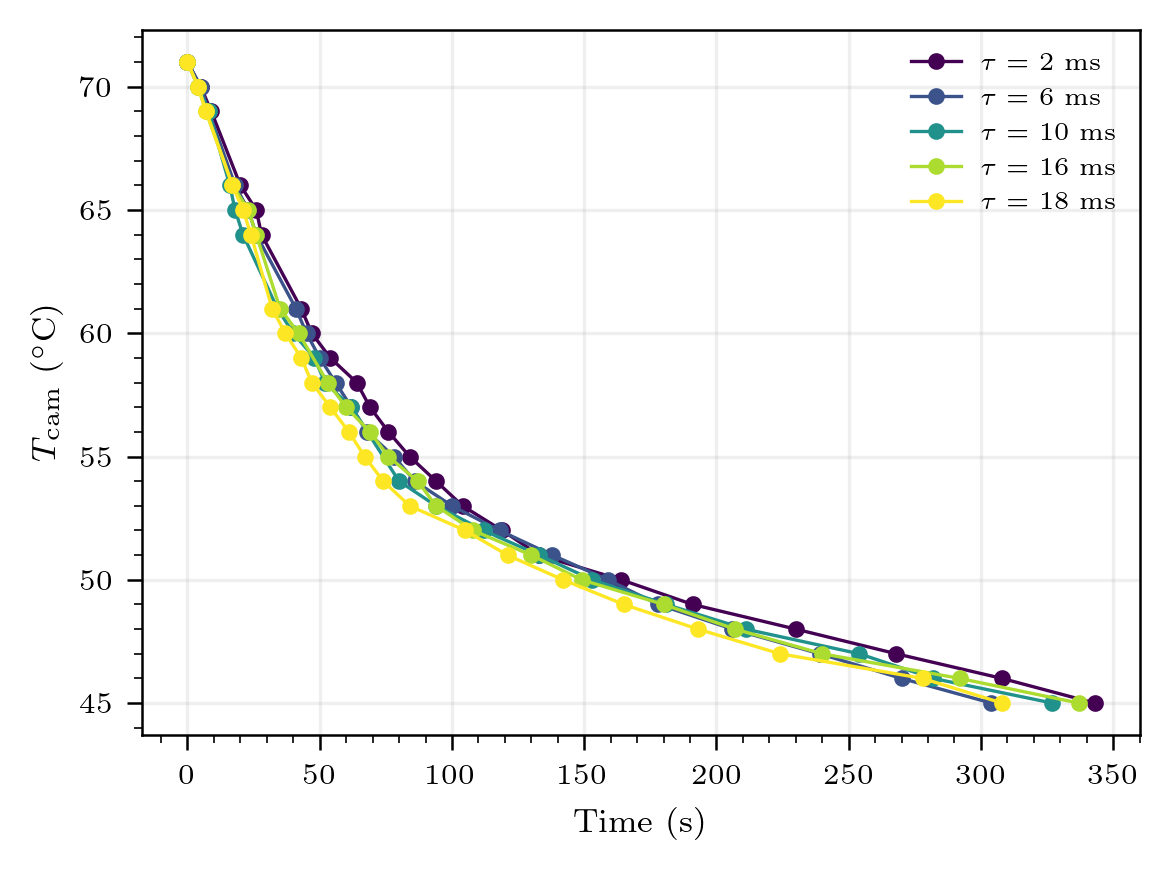

In [96]:
# --- Plot: T_cam vs time for each tau ---
tau_labels = [2, 6, 10, 16, 18]
tau_t_cols  = ['t2', 't6', 't10', 't16', 't18']

norm_tau = mcolors.Normalize(vmin=min(tau_labels), vmax=max(tau_labels))
cmap_tau = cm.viridis

fig, ax = plt.subplots(figsize=(4, 3))

for tau, col in zip(tau_labels, tau_t_cols):
    t_col = cal_df[col].values.astype(float)
    valid = ~np.isnan(t_col)
    t_zeroed = t_col[valid] - t_col[valid].min()
    color = cmap_tau(norm_tau(tau))
    ax.plot(t_zeroed, T_cal[valid], 'o-', color=color,
            lw=0.8, markersize=3, label=rf'$\tau={tau}$ ms')

ax.set_xlabel(r'Time (s)')
ax.set_ylabel(r'$T_\mathrm{cam}$ ($^\circ$C)')
ax.legend(fontsize=6, loc='upper right')
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig('bwax_Tcam_vs_time.png', dpi=300, bbox_inches='tight')
fig.savefig('bwax_Tcam_vs_time.pdf', bbox_inches='tight')
plt.show()
